# BigBasket Product Analysis - Exploratory Data Analysis (EDA)

## Project Objective

The objective of this project is to analyze BigBasket product data and uncover insights related to:

- Product pricing patterns
- Discounts and promotional strategies
- Product ratings and customer perception
- Category-wise performance
- Brand-wise discount trends

This analysis demonstrates data cleaning, feature engineering, exploratory data analysis, visualization, and business insight generation using Python.


# Tools & Libraries Used

- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn

## EDA Workflow

1. Data Understanding
2. Data Cleaning
3. Missing Value Treatment
4. Feature Engineering
5. Univariate Analysis
6. Outlier Detection
7. Bivariate Analysis
8. Correlation Analysis
9. Business Insights
10. Recommendations
11. Conclusion


# Step 1: Importing the libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Step 2: Importing the Dataset

In [2]:
df = pd.read_csv('BigBasket Products.csv')
df.head()

,index,product,category,sub_category,brand,sale_price,market_price,type,rating,description
0,1,Garlic Oil - Vegetarian Capsule 500 mg,Beauty & Hygiene,Hair Care,Sri Sri Ayurveda,220.0,220.0,Hair Oil & Serum,4.1,This Product contains Garlic Oil that is known...
1,2,Water Bottle - Orange,"Kitchen, Garden & Pets",Storage & Accessories,Mastercook,180.0,180.0,Water & Fridge Bottles,2.3,"Each product is microwave safe (without lid), ..."
2,3,"Brass Angle Deep - Plain, No.2",Cleaning & Household,Pooja Needs,Trm,119.0,250.0,Lamp & Lamp Oil,3.4,"A perfect gift for all occasions, be it your m..."
3,4,Cereal Flip Lid Container/Storage Jar - Assort...,Cleaning & Household,Bins & Bathroom Ware,Nakoda,149.0,176.0,"Laundry, Storage Baskets",3.7,Multipurpose container with an attractive desi...
4,5,Creme Soft Soap - For Hands & Body,Beauty & Hygiene,Bath & Hand Wash,Nivea,162.0,162.0,Bathing Bars & Soaps,4.4,Nivea Creme Soft Soap gives your skin the best...


# Step 3: Understanding Dataset Structure 

In [3]:
df.shape

(27555, 10)

In [4]:
df.columns

Index(['index', 'product', 'category', 'sub_category', 'brand', 'sale_price',
       'market_price', 'type', 'rating', 'description'],
      dtype='object')

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27555 entries, 0 to 27554
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   index         27555 non-null  int64  
 1   product       27554 non-null  object 
 2   category      27555 non-null  object 
 3   sub_category  27555 non-null  object 
 4   brand         27554 non-null  object 
 5   sale_price    27549 non-null  float64
 6   market_price  27555 non-null  float64
 7   type          27555 non-null  object 
 8   rating        18919 non-null  float64
 9   description   27440 non-null  object 
dtypes: float64(3), int64(1), object(6)
memory usage: 2.1+ MB


In [6]:
df.describe()

,index,sale_price,market_price,rating
count,27555.00000,27549.000000,27555.000000,18919.000000
mean,13778.00000,334.648391,382.056664,3.943295
std,7954.58767,1202.102113,581.730717,0.739217
min,1.00000,2.450000,3.000000,1.000000
25%,6889.50000,95.000000,100.000000,3.700000
50%,13778.00000,190.320000,220.000000,4.100000
75%,20666.50000,359.000000,425.000000,4.300000
max,27555.00000,112475.000000,12500.000000,5.000000


# Step 4: Checking Missing Values

In [7]:
df.isnull().sum()

index              0
product            1
category           0
sub_category       0
brand              1
sale_price         6
market_price       0
type               0
rating          8636
description      115
dtype: int64

# Step 5: Handaling Missing Values 

In [8]:
# Remove rows where essential fields are missing
df = df.dropna(subset=['product', 'sale_price'])

# Fill missing brand names
df['brand'] = df['brand'].fillna('Unknown')

# Preserve original rating column and create filled version
df['rating_filled'] = df['rating'].fillna(df['rating'].median())

# Fill missing descriptions
df['description'] = df['description'].fillna('No description available')

In [9]:
df.isnull().sum()

index               0
product             0
category            0
sub_category        0
brand               0
sale_price          0
market_price        0
type                0
rating           8633
description         0
rating_filled       0
dtype: int64

# Step 6 : Duplicate Check

In [10]:
 df.duplicated().sum()

np.int64(0)

# Step 7 : Feature Engineering

In [11]:
# creating new columns

df['discount_amount'] = df['market_price'] - df['sale_price']

In [12]:
df['discount_percent'] = (
    (df['market_price'] - df['sale_price']) / df['market_price']
) * 100

In [13]:
df[['market_price','sale_price', 'discount_amount','discount_percent']].head()

,market_price,sale_price,discount_amount,discount_percent
0,220.0,220.0,0.0,0.000000
1,180.0,180.0,0.0,0.000000
2,250.0,119.0,131.0,52.400000
3,176.0,149.0,27.0,15.340909
4,162.0,162.0,0.0,0.000000


# Step 8 : Univariate Analysis

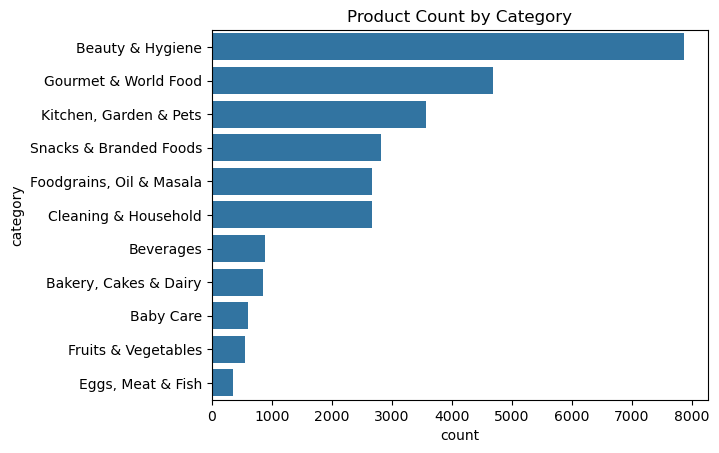

In [14]:
sns.countplot(
    y=df['category'],
    order=df['category'].value_counts().index)

plt.title('Product Count by Category')
plt.show()

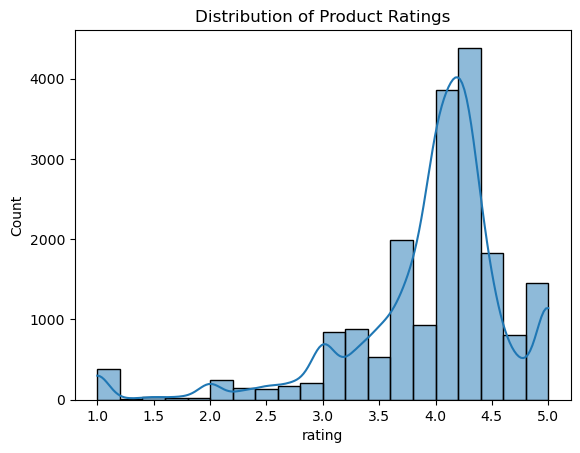

In [15]:
sns.histplot(df['rating'], bins=20, kde=True)

plt.title('Distribution of Product Ratings')
plt.show()

# Step 9 : bivariate Analysis

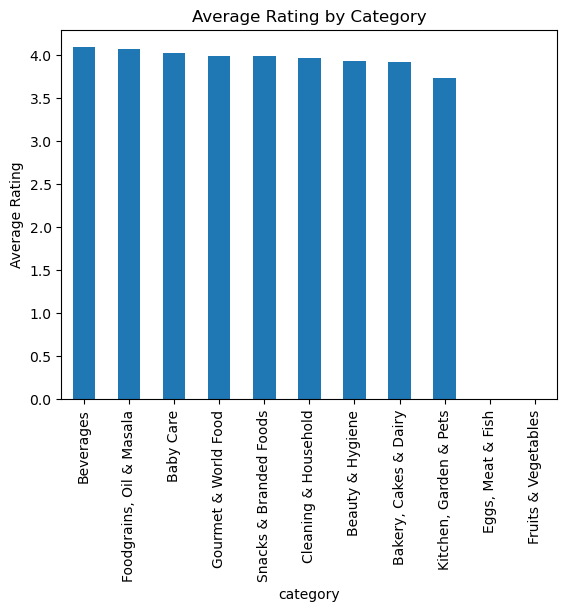

In [16]:
# Category vs Average Rating
avg_rating = df.groupby('category')['rating'].mean().sort_values(ascending=False)
avg_rating.plot(kind='bar')

plt.title('Average Rating by Category')
plt.ylabel('Average Rating')
plt.show()

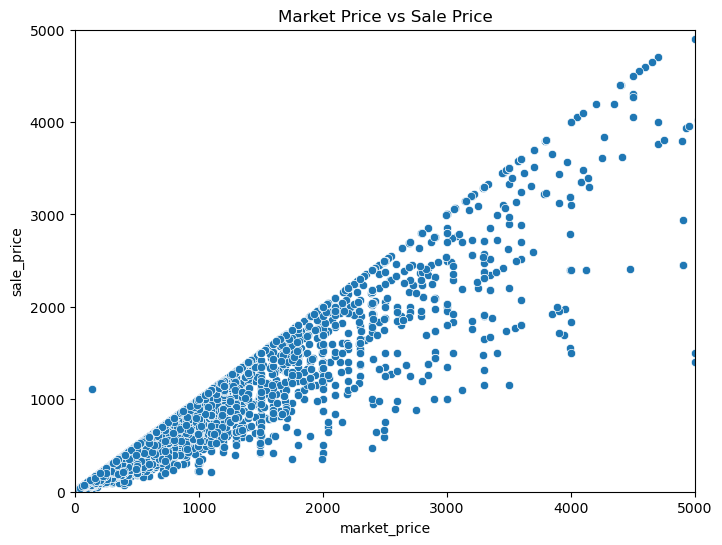

In [17]:
# Market Price VS Sale Price

plt.figure(figsize=(8,6))

sns.scatterplot(
    x=df['market_price'],
    y=df['sale_price']
)

plt.title('Market Price vs Sale Price')
plt.xlim(0, 5000)
plt.ylim(0, 5000)
plt.show()

Text(0.5, 1.0, 'Top 15 Brands by Product Count')

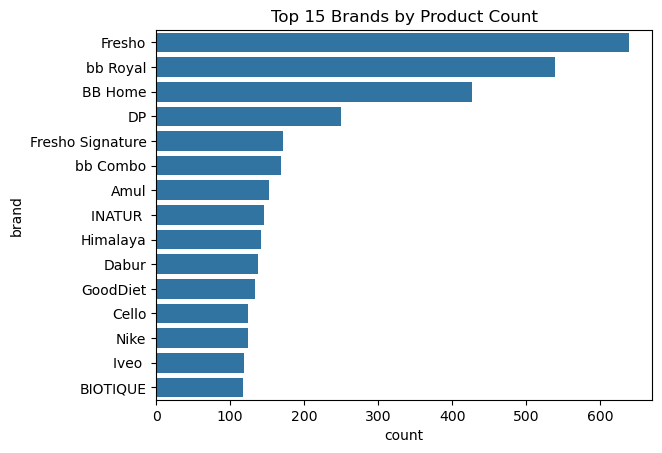

In [18]:
# Top Brands by Product Count
sns.countplot(
    y = df['brand'],
    order = df['brand'].value_counts().head(15).index)

plt.title('Top 15 Brands by Product Count')

# step 10: Multivariate Analysis 

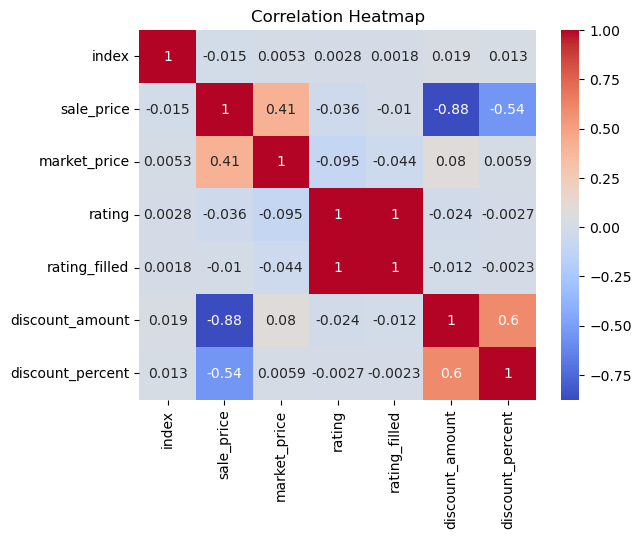

In [19]:
# correlation Heatmap

numeric_df = df.select_dtypes(include=np.number)

sns.heatmap(numeric_df.corr(),
            annot = True,
            cmap = 'coolwarm'
           )
plt.title('Correlation Heatmap')
plt.show()

# Step 11 : Outlier Detection

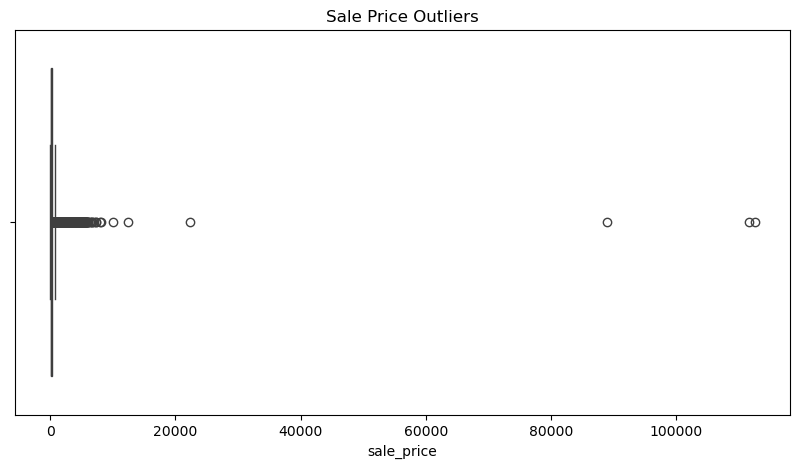

In [20]:
plt.figure(figsize=(10,5))
sns.boxplot(x=df['sale_price'])

plt.title('Sale Price Outliers')
plt.show()

# Step 12 : Business Insights

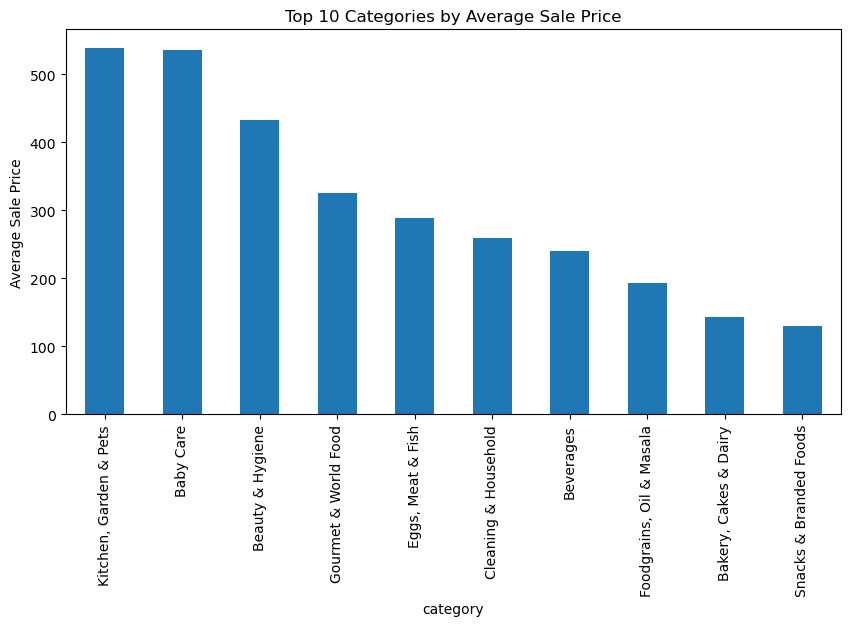

category
Kitchen, Garden & Pets      538.746260
Baby Care                   534.946180
Beauty & Hygiene            432.788768
Gourmet & World Food        324.544842
Eggs, Meat & Fish           288.897486
Cleaning & Household        259.543992
Beverages                   239.803925
Foodgrains, Oil & Masala    193.222516
Bakery, Cakes & Dairy       142.802750
Snacks & Branded Foods      129.616097
Name: sale_price, dtype: float64

In [21]:
# Category-wise Average Price
avg_price = df.groupby('category')['sale_price'].mean().sort_values(ascending=False)

plt.figure(figsize=(10,5))
avg_price.head(10).plot(kind='bar')
plt.title('Top 10 Categories by Average Sale Price')
plt.ylabel('Average Sale Price')
plt.show()

avg_price.head(10)


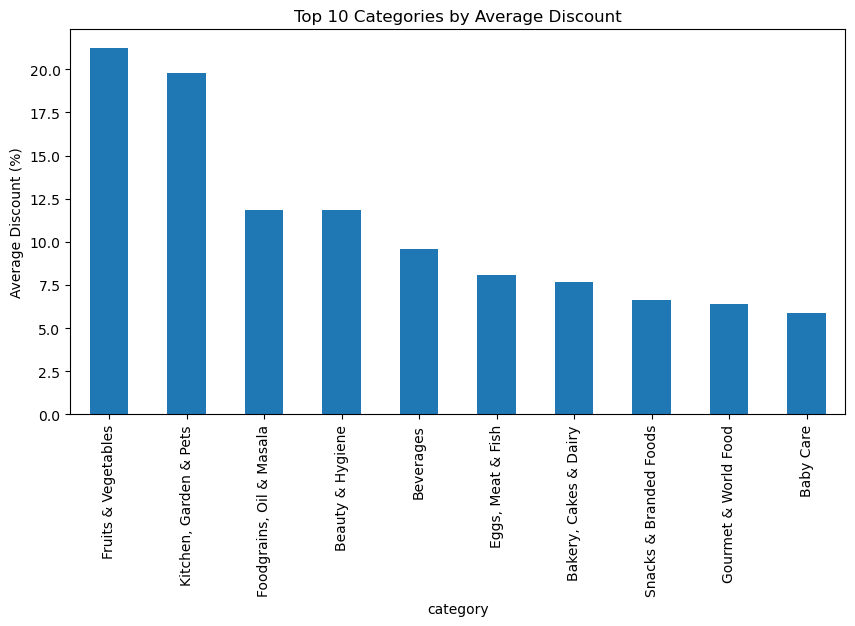

category
Fruits & Vegetables         21.249745
Kitchen, Garden & Pets      19.765466
Foodgrains, Oil & Masala    11.843247
Beauty & Hygiene            11.829953
Beverages                    9.559384
Eggs, Meat & Fish            8.057709
Bakery, Cakes & Dairy        7.664125
Snacks & Branded Foods       6.645312
Gourmet & World Food         6.420640
Baby Care                    5.852684
Name: discount_percent, dtype: float64

In [22]:
# Category-wise Average Discount
avg_discount = df.groupby('category')['discount_percent'].mean().sort_values(ascending=False)

plt.figure(figsize=(10,5))
avg_discount.head(10).plot(kind='bar')
plt.title('Top 10 Categories by Average Discount')
plt.ylabel('Average Discount (%)')
plt.show()

avg_discount.head(10)


In [23]:
# Brand-wise Discount Analysis
brand_discount = df.groupby('brand')['discount_percent'].mean().sort_values(ascending=False)

brand_discount.head(10)


brand
Mud             80.000000
Jensons         74.253281
Mansaa          71.250764
Triones         69.766040
Mondsub         69.000000
Spartan         67.067067
Lexton          67.026262
Bertolli        66.689897
HealthChoice    66.688896
Care 4 All      65.101403
Name: discount_percent, dtype: float64

# Step 13 : Additional Distribution Analysis

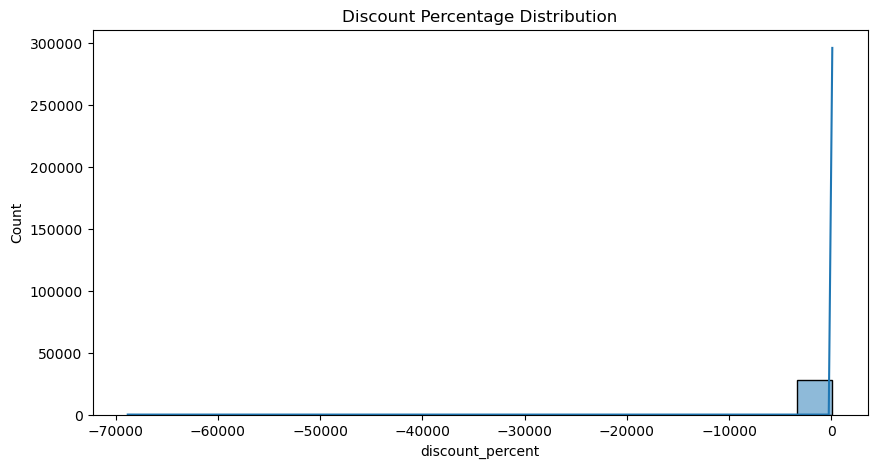

In [24]:
plt.figure(figsize=(10,5))

sns.histplot(df['discount_percent'], bins=20, kde=True)

plt.title('Discount Percentage Distribution')
plt.show()


# Step 14 : Advanced Outlier Detection

In [25]:
Q1 = df['sale_price'].quantile(0.25)
Q3 = df['sale_price'].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df[(df['sale_price'] < lower) | (df['sale_price'] > upper)]

print('Number of Outliers:', len(outliers))
outliers.head()


Number of Outliers: 2205


,index,product,category,sub_category,brand,sale_price,market_price,type,rating,description,rating_filled,discount_amount,discount_percent
8,9,Biotin & Collagen Volumizing Hair Shampoo + Bi...,Beauty & Hygiene,Hair Care,StBotanica,1098.0,1098.0,Shampoo & Conditioner,3.5,"An exclusive blend with Vitamin B7 Biotin, Hyd...",3.5,0.0,0.0
47,48,Colour Catcher Sheets,Cleaning & Household,All Purpose Cleaners,Dylon,799.0,799.0,Imported Cleaners,4.0,1. Prevents Colour Run Accidents Colours that ...,4.0,0.0,0.0
51,52,Peach Syrup,Gourmet & World Food,Drinks & Beverages,Pekers,850.0,850.0,Gourmet Juices & Drinks,4.2,Pekers peach syrup takes you on a historical t...,4.2,0.0,0.0
69,70,"Padded Harness - 3/4 inch, Grey Colour","Kitchen, Garden & Pets",Pet Food & Accessories,Glenand,840.0,840.0,Pet Collars & Leashes,NaN,These are soft padded harness for your active ...,4.1,0.0,0.0
91,92,Hard Anodised Ezee-Pour Saucepan With Lid - L88,"Kitchen, Garden & Pets",Cookware & Non Stick,Hawkins Futura,864.5,910.0,Tawa & Sauce Pan,4.6,Futura Hard Anodised Saucepan comes with a spo...,4.6,45.5,5.0


# Step 15 : Business Questions

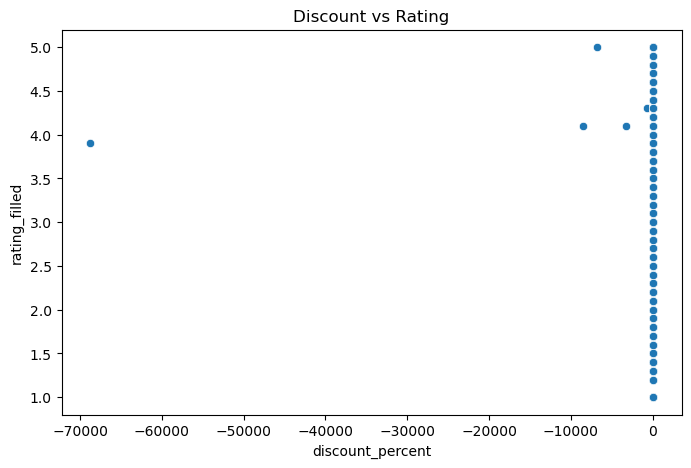

In [26]:
# Relationship Between Discount and Rating
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x='discount_percent',
    y='rating_filled'
)

plt.title('Discount vs Rating')
plt.show()


In [27]:
# Top Rated Products
df.nlargest(
    10,
    'rating_filled'
)[['product','brand','rating_filled']]


,product,brand,rating_filled
12,"Face Wash - Oil Control, Active",Oxy,5.0
16,Smooth Skin Oil - For Dry Skin,Aroma Treasures,5.0
24,Veggie Cutter,IRICH,5.0
44,Plain Green Olives,Figaro,5.0
92,Topp Up Milk - Elaichi,Gowardhan,5.0
111,SPF 15 Sunscreen Lotion,Elovera,5.0
177,Soap,Mysore Sandal,5.0
213,Apple Cider Vinegar - Raw Unfiltered Unpasteur...,Zoe,5.0
226,Lavender & Vanilla Handmade Luxury Soap,StBotanica,5.0
229,Chyawan Fit Sugarfree Chyawanprash - Natural I...,Baidyanath,5.0


In [28]:
# Most Expensive Products
df.nlargest(
    10,
    'sale_price'
)[['product','brand','sale_price']]


,product,brand,sale_price
1249,Beard Kit,Uncle Tony,112475.00
248,4mm Aluminium Induction Base Chapati Roti Tawa...,HAZEL,111649.00
436,"Balloon - Polka Dot, 12 Inch",B Vishal,88899.00
288,Arrabbiata Tomato Pasta Sauce With Chilli,Montanini,22325.00
25301,Bravura Clipper,Wahl,12500.00
21761,Pet Food - N&D Team Breeder Puppy Top Farmina,Farmina,10090.00
12669,Epilator SE9-9961 Legs-Body-Face,Braun,8184.44
23082,"Gas Stove-4 Burner Royale Plus Schott Glass, B...",Prestige,7999.00
2781,Extra Virgin Olive Oil,Abbies,7299.00
25797,"4 Burner Gas Stove - Marvel Plus Glass Tables,...",Prestige,7270.00


# Step 16 : Conclusion

## Key Findings

1. Analyzed product pricing, discounts, ratings and categories.
2. Identified categories with the highest average prices.
3. Identified categories and brands offering the largest discounts.
4. Studied the relationship between discounts and ratings.
5. Detected outliers in sale prices using the IQR method.
6. Identified top-rated and most expensive products.
7. Generated actionable business insights from retail product data.


# Business Recommendations

Based on the analysis:

### Recommendation 1
Focus promotional campaigns on highly rated products that currently receive lower visibility.

### Recommendation 2
Review categories with extremely high discounts to ensure profitability is maintained.

### Recommendation 3
Use category-level pricing insights to optimize product positioning.

### Recommendation 4
Investigate high-price outliers and determine whether premium pricing is justified.

### Recommendation 5
Promote top-rated products more aggressively through featured listings and recommendations.


# Executive Summary

This project analyzed BigBasket product data through a complete EDA workflow.

Key achievements:

- Cleaned and prepared raw retail data.
- Handled missing values and duplicates.
- Created new business metrics such as discount amount and discount percentage.
- Explored distributions, outliers and relationships between variables.
- Identified category-wise and brand-wise trends.
- Generated business-focused insights and recommendations.

This project demonstrates practical Data Analyst skills in data cleaning, exploratory analysis, visualization, and business storytelling.
